In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-gaussian-filtered')

print('Data source import complete.')
print(sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path)

Data source import complete.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random, os
import shutil
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv(r'/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/train.csv')

diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

diagnosis_dict = {
    0: 'No_DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate_DR',
}


df['binary_type'] =  df['diagnosis'].map(diagnosis_dict_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
df.head()

,id_code,diagnosis,binary_type,type
0,000c1434d8d7,2,DR,Moderate
1,001639a390f0,4,DR,Proliferate_DR
2,0024cdab0c1e,1,DR,Mild
3,002c21358ce6,0,No_DR,No_DR
4,005b95c28852,0,No_DR,No_DR


<Axes: ylabel='binary_type'>

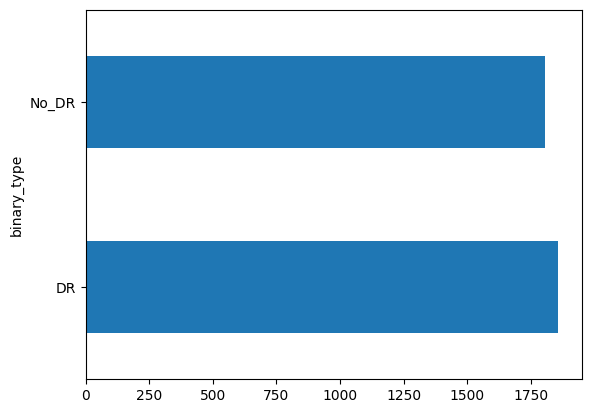

In [8]:
df['binary_type'].value_counts().plot(kind='barh')

In [9]:
train_intermediate, val = train_test_split(df, test_size = 0.15, stratify = df['type'])
train, test = train_test_split(train_intermediate, test_size = 0.15 / (1 - 0.15), stratify = train_intermediate['type'])

print(train['type'].value_counts(), '\n')
print(test['type'].value_counts(), '\n')
print(val['type'].value_counts(), '\n')


type
No_DR             1263
Moderate           699
Mild               258
Proliferate_DR     207
Severe             135
Name: count, dtype: int64 

type
No_DR             271
Moderate          150
Mild               56
Proliferate_DR     44
Severe             29
Name: count, dtype: int64 

type
No_DR             271
Moderate          150
Mild               56
Proliferate_DR     44
Severe             29
Name: count, dtype: int64 



In [10]:
base_dir = 'images'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
os.makedirs(train_dir)

if os.path.exists(val_dir):
    shutil.rmtree(val_dir)
os.makedirs(val_dir)

if os.path.exists(test_dir):
    shutil.rmtree(test_dir)
os.makedirs(test_dir)

In [11]:
src_dir = r'/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images'
for index, row in train.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + ".png"
    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(train_dir, binary_diagnosis)
    os.makedirs(dstfile, exist_ok = True)
    shutil.copy(srcfile, dstfile)

for index, row in val.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + ".png"
    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(val_dir, binary_diagnosis)
    os.makedirs(dstfile, exist_ok = True)
    shutil.copy(srcfile, dstfile)

for index, row in test.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + ".png"
    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(test_dir, binary_diagnosis)
    os.makedirs(dstfile, exist_ok = True)
    shutil.copy(srcfile, dstfile)

In [13]:
train_path = 'images/train'
val_path = 'images/val'
test_path = 'images/test'

train_batches = ImageDataGenerator(rescale = 1./255).flow_from_directory(train_path, target_size=(224,224), shuffle = True)
val_batches = ImageDataGenerator(rescale = 1./255).flow_from_directory(val_path, target_size=(224,224), shuffle = True)
test_batches = ImageDataGenerator(rescale = 1./255).flow_from_directory(test_path, target_size=(224,224), shuffle = False)


Found 2562 images belonging to 2 classes.
Found 550 images belonging to 2 classes.
Found 550 images belonging to 2 classes.


In [14]:
model = tf.keras.Sequential([
    layers.Conv2D(8, (3,3), padding="valid", input_shape=(224,224,3), activation = 'relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(16, (3,3), padding="valid", activation = 'relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(32, (4,4), padding="valid", activation = 'relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.15),
    layers.Dense(2, activation = 'softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['acc'])

history = model.fit(train_batches,
                    epochs=30,
                    validation_data=val_batches)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - acc: 0.8138 - loss: 0.4129 - val_acc: 0.5073 - val_loss: 0.7054
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - acc: 0.9224 - loss: 0.2041 - val_acc: 0.5218 - val_loss: 0.6397
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - acc: 0.9418 - loss: 0.1633 - val_acc: 0.8327 - val_loss: 0.5502
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - acc: 0.9571 - loss: 0.1295 - val_acc: 0.7564 - val_loss: 0.4988
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - acc: 0.9529 - loss: 0.1297 - val_acc: 0.7745 - val_loss: 0.4567
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - acc: 0.9606 - loss: 0.1062 - val_acc: 0.8782 - val_loss: 0.3209
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - acc: 0.9714 - loss: 0.0886 - val_acc: 0.9073 - val_loss: 0.2233
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - acc: 0.9744 - loss: 0.0827 - val_acc: 0.9145 - val_loss: 0.2266
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - ac

In [15]:
model.save('binary_CNN_model.h5')

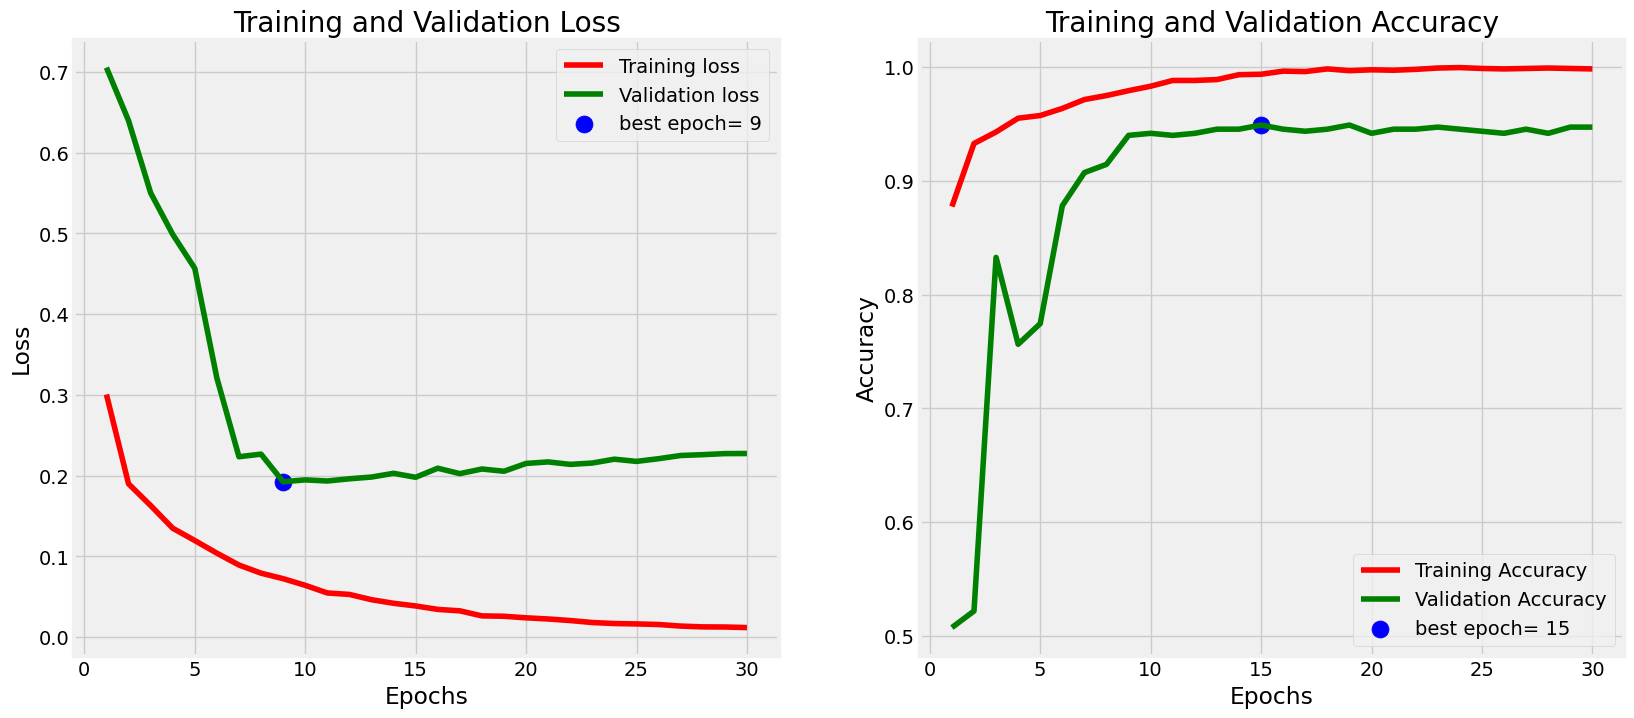

In [16]:
# Define needed variables
tr_acc = history.history['acc']
tr_loss = history.history['loss']
val_acc = history.history['val_acc']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [17]:
train_score = model.evaluate(train_batches, verbose= 1)
valid_score = model.evaluate(val_batches, verbose= 1)
test_score = model.evaluate(test_batches, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - acc: 0.9997 - loss: 0.0076
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - acc: 0.9455 - loss: 0.2175
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - acc: 0.9558 - loss: 0.1887
Train Loss:  0.008841097354888916
Train Accuracy:  0.9992193579673767
--------------------
Validation Loss:  0.22733928263187408
Validation Accuracy:  0.9472727179527283
--------------------
Test Loss:  0.23149973154067993
Test Accuracy:  0.9545454382896423


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step


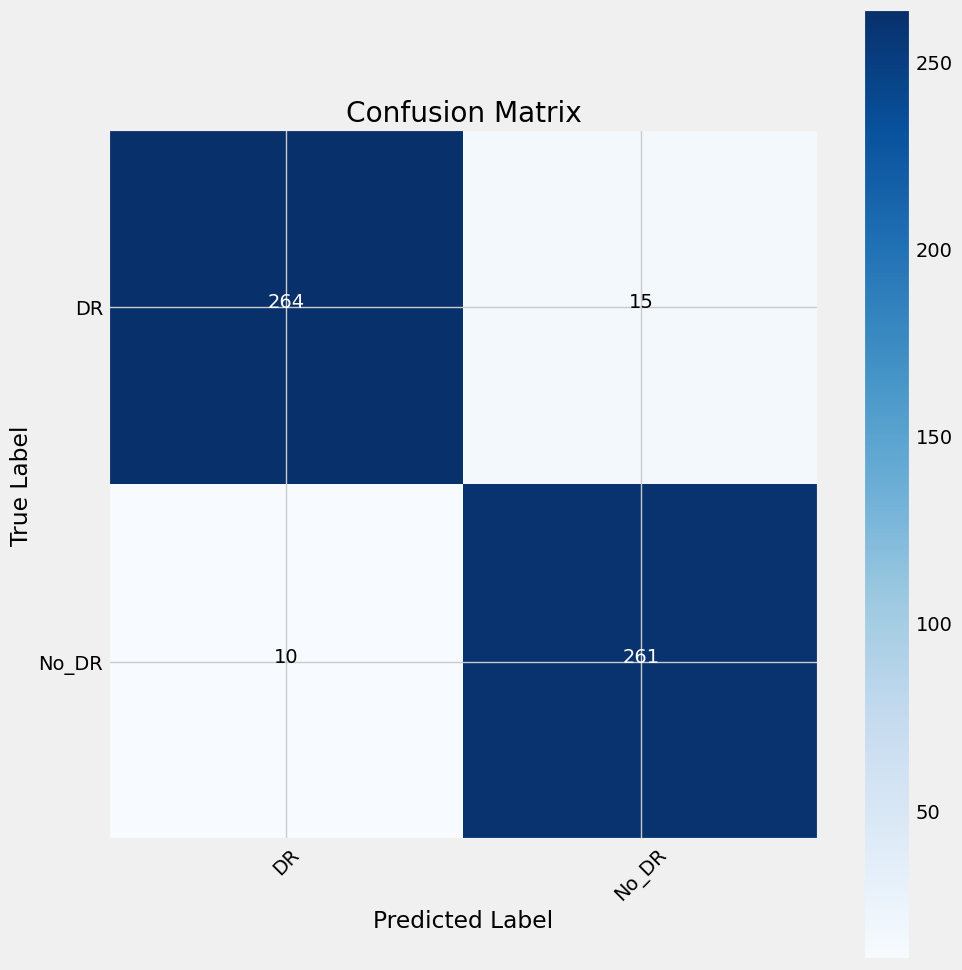

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

preds = model.predict(test_batches, steps=len(test_batches))
y_pred = np.argmax(preds, axis=1)

g_dict = test_batches.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_batches.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [19]:
# Classification report
print(classification_report(test_batches.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

          DR       0.96      0.95      0.95       279
       No_DR       0.95      0.96      0.95       271

    accuracy                           0.95       550
   macro avg       0.95      0.95      0.95       550
weighted avg       0.95      0.95      0.95       550

